In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# torch.cuda.empty_cache()

# Check Data Module

In [3]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')

INFO     | _get_names | Image Pair Counts : MGO01_low_light cam0 : 535
INFO     | _get_names | Image Pair Counts : MGO01_low_light cam1 : 562
INFO     | _get_names | Image Pair Counts : MOO06_inspect_hard cam0 : 556
INFO     | _get_names | Image Pair Counts : MOO06_inspect_hard cam1 : 555
INFO     | _get_names | Image Pair Counts : MOO01_hand_puncher_1 cam0 : 609
INFO     | _get_names | Image Pair Counts : MOO01_hand_puncher_1 cam1 : 609
INFO     | setup | Train Dataset       : 3426 samples
INFO     | _get_names | Image Pair Counts : MOO07_mapping_easy cam0 : 89
INFO     | _get_names | Image Pair Counts : MOO07_mapping_easy cam1 : 89
INFO     | _get_names | Image Pair Counts : MOO08_mapping_hard cam0 : 103
INFO     | _get_names | Image Pair Counts : MOO08_mapping_hard cam1 : 100
INFO     | _get_names | Image Pair Counts : MGO08_mapping_hard cam0 : 111
INFO     | _get_names | Image Pair Counts : MGO08_mapping_hard cam1 : 110
INFO     | _get_names | Image Pair Counts : MGO07_mapping_easy

In [4]:
dl = dm.train_dataloader()

In [5]:
batch = next(iter(dl))

In [6]:
reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

rotations = batch.rotations
print(rotations.shape)

torch.Size([102, 3, 32, 32]) torch.Size([102, 3, 32, 32])
torch.Size([102, 2]) torch.Size([102, 2])
torch.Size([102])


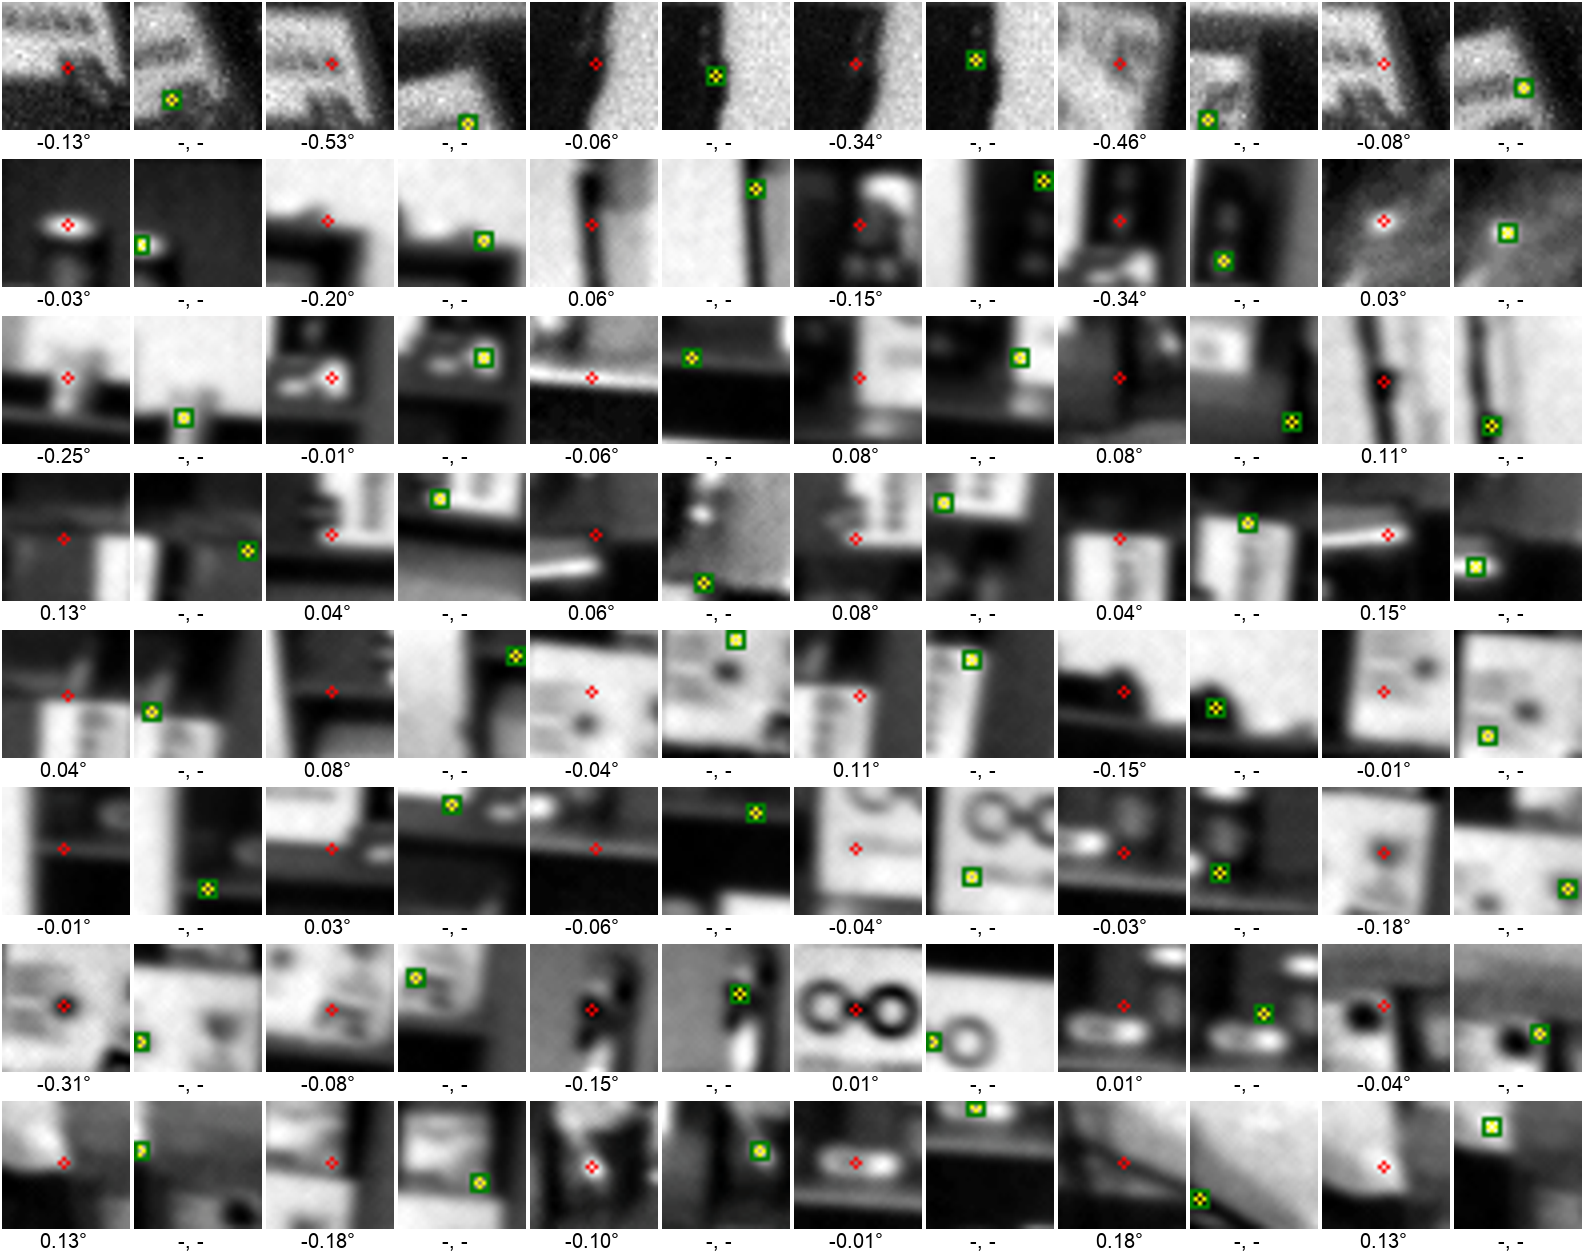

In [7]:
# batch = next(iter(dl))

count = 24 * 2

# radians to degrees
# print(batch.rotations[:count] * (180 / torch.pi))
# print(batch.rotations[:count])

show_batch(
    reference_patches, target_patches,
    patch_level_reference_coords, patch_level_target_coords,
    patch_level_target_coords,
    rotations_true=batch.rotations,
    rotations=None,
    limit_count=count, 
    n_columns=6,
)

In [8]:
# for index, batch in enumerate(dl):
#     print(f'-- Batch Index {index} -----')
#     reference_patches = batch.reference_patches
#     target_patches = batch.target_patches
#     print(reference_patches.shape, target_patches.shape) 

#     patch_level_reference_coords = batch.patch_level_reference_coords
#     patch_level_target_coords = batch.patch_level_target_coords
#     print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

#     rotations = batch.rotations
#     print(rotations.shape)

In [9]:
dm.teardown()

# Check Model

In [10]:
from src import Light
light = Light()

In [11]:
from utils import count_params
count_params(light.model)

420612

In [12]:
print('Model Inputs')
print(f'reference_patches shape : {reference_patches.shape}')
print(f'target_patches shape : {target_patches.shape}')
print(f'patch_level_reference_coords shape : {patch_level_reference_coords.shape}')

reference_patches, target_patches, patch_level_reference_coords = reference_patches.to('cuda'), target_patches.to('cuda'), patch_level_reference_coords.to('cuda')

print('Model Outputs')

target_coords, target_rotation, target_confidence = light(
    reference_patches, 
    target_patches, 
    patch_level_reference_coords
)

print(f'target_coords shape : {target_coords.shape}')
print(f'target_rotation shape : {target_rotation.shape}')
print(f'target_confidence shape : {target_confidence.shape}')

Model Inputs
reference_patches shape : torch.Size([102, 3, 32, 32])
target_patches shape : torch.Size([102, 3, 32, 32])
patch_level_reference_coords shape : torch.Size([102, 2])
Model Outputs
target_coords shape : torch.Size([102, 2])
target_rotation shape : torch.Size([102, 1])
target_confidence shape : torch.Size([102, 1])


# Confidence

In [13]:
patch_level_reference_coords[:1], target_coords[:1]

(tensor([[16.5000, 16.5000]], device='cuda:0'),
 tensor([[ 0.3908, -0.1362]], device='cuda:0', grad_fn=<SliceBackward0>))

In [14]:
std_dev = 6.0
covariance_matrix = torch.diag(torch.tensor([std_dev ** 2, std_dev ** 2], device=patch_level_reference_coords.device))

gaussian = torch.distributions.MultivariateNormal(
    loc=patch_level_reference_coords, 
    covariance_matrix=covariance_matrix
)

In [18]:
X = (target_coords + 1) * 15.5

# X = patch_level_reference_coords + 10  # for testing std dev

# d = torch.arange(patch_level_reference_coords.shape[0], device=patch_level_reference_coords.device).unsqueeze(1)
# X = patch_level_reference_coords + d  # for testing std dev

raw_probabilities = torch.exp(gaussian.log_prob(X))

In [19]:
# Y = patch_level_reference_coords / 31.0
# max_probabilities = torch.exp(gaussian.log_prob(Y))
max_probabilities = torch.exp(gaussian.log_prob(patch_level_reference_coords))

# Normalize probabilities to make p = 1 when coords_pred = coords
normalized_probabilities = raw_probabilities / (max_probabilities + 0.000001)

In [20]:
normalized_probabilities[:15]

tensor([0.6126, 0.7204, 0.9740, 0.5073, 0.3823, 0.3366, 0.9507, 0.9131, 0.8828,
        0.3687, 0.8258, 0.1339, 0.5354, 0.8873, 0.5854], device='cuda:0',
       grad_fn=<SliceBackward0>)